## Breast cancer Diagnosis Prediction using Machine learning

This notebook presents an exploratory data analysis and **machine learning** classification on the breast cancer Wisconsin dataset using Python and scikit-learn.


In [1]:

# Import required libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer


In [2]:
# Load the breast cancer dataset
data=load_breast_cancer()


In [3]:
# Inspect the availabe elements in the dataset
data.keys() 


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

## Data Preparation

In [4]:
# Extract the feature matrix and target variable , and convert the data into a pandas Dataframe
x=data.data
y=data.target

df=pd.DataFrame(x,columns=data.feature_names)  
df["target"]=y 
df.head() 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Verify the dimensions of the feature matrix , target vector , and DataFrame
print("x shape:",x.shape) 
print("y shape:",y.shape)
print("df shape:", df.shape)


x shape: (569, 30)
y shape: (569,)
df shape: (569, 31)


In [6]:
# Examine the distribution of the target classes
df["target"].value_counts() 

target
1    357
0    212
Name: count, dtype: int64

In [7]:
# Create a categorical diagnosis column by mapping numeric target values to labels
df["diagnosis"]=df["target"].map({0:"malignant",1:"benign"}) 
df[["target","diagnosis"]].head()


,target,diagnosis
0,0,malignant
1,0,malignant
2,0,malignant
3,0,malignant
4,0,malignant


In [8]:
# Calculate and present the frequency and percentage distribution of diagnosis classes
counts=df["diagnosis"].value_counts()
percent=counts/counts.sum() *100 
print(counts)
print("\n Percent %:")
print(percent.round(2)) 

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

 Percent %:
diagnosis
benign       62.74
malignant    37.26
Name: count, dtype: float64



## Dataset Overview
 dataset :**sklearn breast cancer dataset**
 
 Total samples:**569**
 
 Features:**30 tumor measurements**
 
 Classes:
  -**malignant**(cancerous)
  -**benign**(non cancerous)
  
 Class distribution:
  -malignant:**212 (37.26%)**
  -benign:**357(62.74%)**
  
 Observation:
 The dataset it slightly imbalanced but still suitable for classification models


## Exploratory Data Analysis

In [9]:
# Quick dataset check: summary statistics and missing values
df.describe()
# Confirm no missing values
df.isnull().sum().head(10)

mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

Text(0.5, 1.0, 'Feature correlation heatmap')

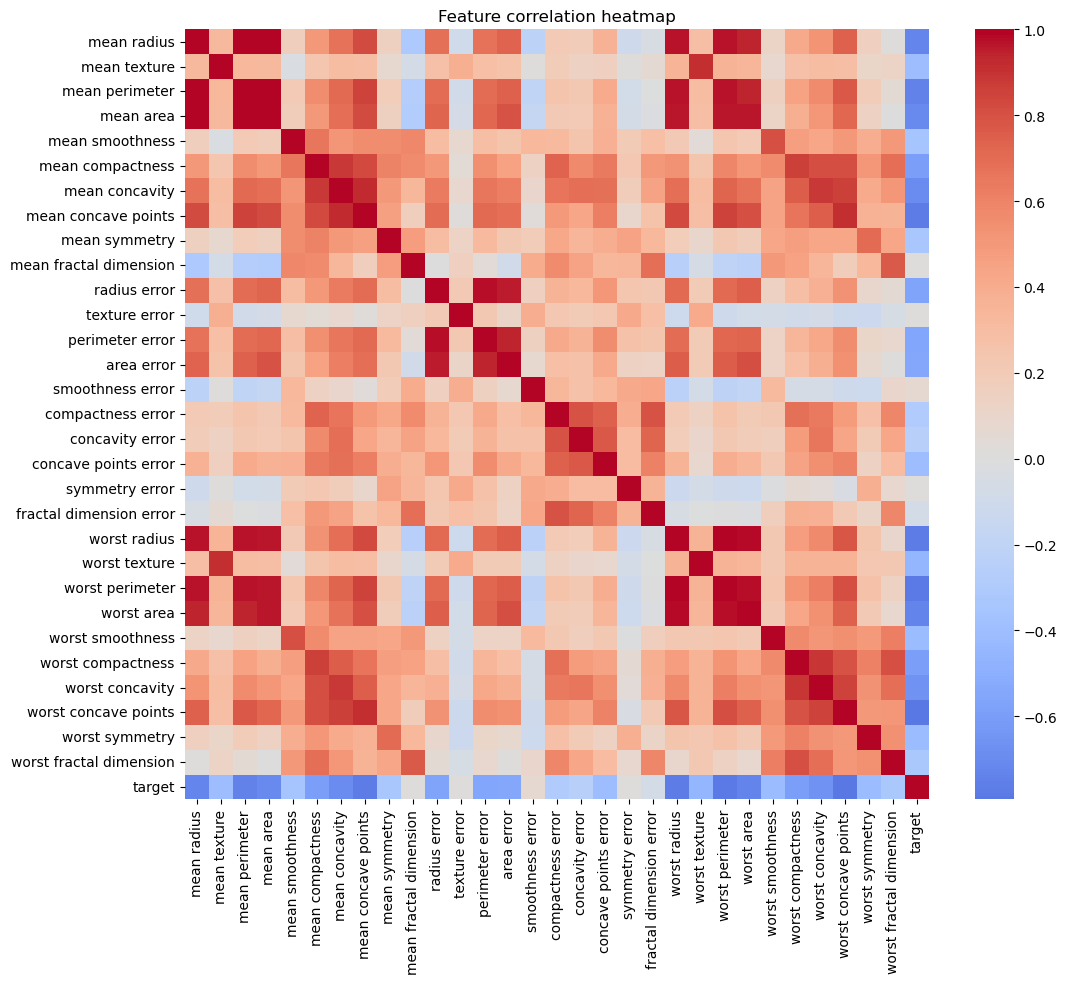

In [10]:
# Correlation between tumor features( remove target since it's not a measurment)
corr= df.drop(columns=["diagnosis"]).corr()    
# Visualize correlations
plt.figure(figsize=(12,10)) 
sns.heatmap(corr, cmap="coolwarm", center=0) 
plt.title("Feature correlation heatmap") 

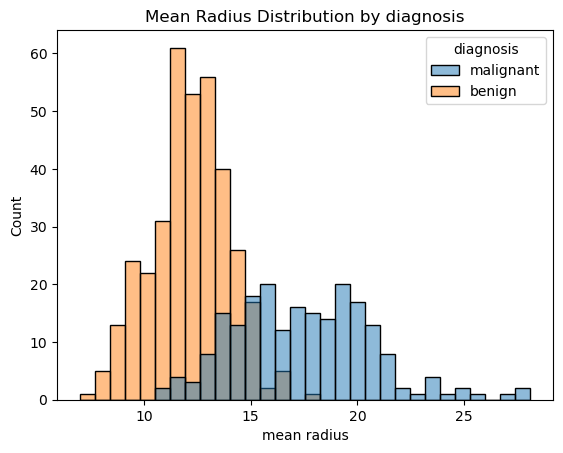

In [11]:
# Plot the distribution of mean tumor radius for benign and malignant diagnoses
sns.histplot(data=df,x="mean radius",hue="diagnosis", bins=30)
plt.title("Mean Radius Distribution by diagnosis")
plt.show()



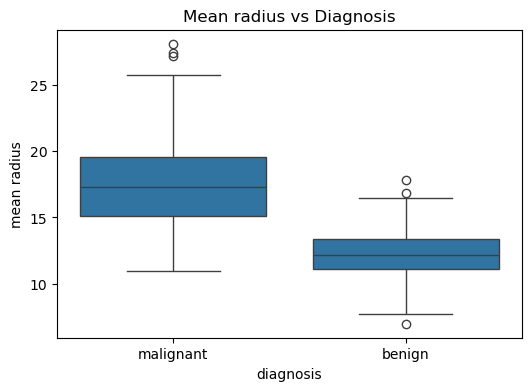

In [12]:
# Plot a boxplot comparing mean tumor radius between benign and malignant diagnoses
plt.figure(figsize=(6,4))
sns.boxplot( data=df, x="diagnosis", y="mean radius")
plt.title("Mean radius vs Diagnosis")
plt.show()

## EDA Insights
- Summary statistics show variation in tumour measurements across samples.

- Correlation analysis show strong relation between **size** related paramaters such as radius, perimeter and area.

- Visualizations show that malignant tumours tend to have **larger** mean radius compared to benign tumours and more variation but benign tumours have the numerical advantage.

- Observing the **histogram** it is clear there is a small overlap between the 2 so we can conclude that in that area, size is not a valid indicator for the diagnosis.



## Machine Learning Preparation


## Train/Test Split


In [13]:
# Split dataset into training and testing sets(80/20)
from sklearn.model_selection import train_test_split  
X=df.drop(columns=["target","diagnosis"])
y=df["target"]
X_train, X_test , y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


## Feature Scaling

In [14]:
# Standarize features so the model treats them equally
from sklearn.preprocessing import StandardScaler 
scaler=StandardScaler() 
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## Baseline Model: Logistic Regression

In [15]:
# Train logistic regresiion classifier
from sklearn.linear_model import LogisticRegression  
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


## ROC Curve

ROC AUC: 0.9953703703703703


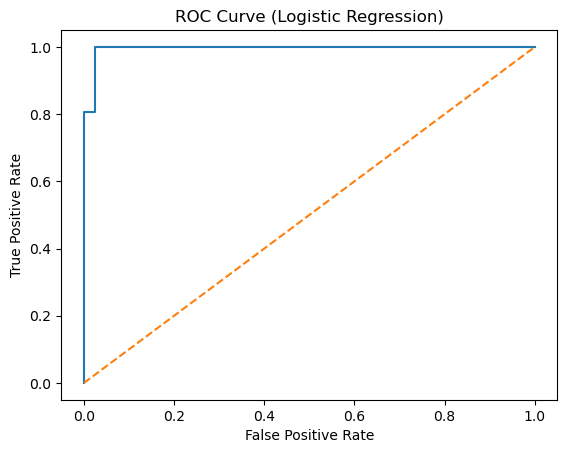

In [16]:
# Evaluate classification performace using ROC curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score 
proba=lr.predict_proba(X_test_scaled)[:,1] 
auc=roc_auc_score(y_test, proba)
print("ROC AUC:",auc)
fpr , tpr,_=roc_curve(y_test, proba)
plt.plot(fpr, tpr)
plt.plot ([0,1],[0,1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.show()


### Model Results Explanation

- The dataset was split using an **80/20 train-test split** with stratification to preserve the class distribution between malignant and benign cases. 

- Feature scaling was applied with StandardScaler to normalize thr input variables before training the model.

- The Logistic Regression classifier was evaluated using the ROC curve and AUC metric.

- The model achieved an **AUC** score of **0.9958** indicating excellent ability to distinguish between malignant and benign tumors.

- The curve reaches the top fast and stays mostly on the left corner so it has excellent discriminative ability.


## Model Comparison

In [17]:
# Define three classification models for comparison:Logistic Regression, SVM(RBF) ,Random Forest
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_score 
models={"Logistic Regression":LogisticRegression(max_iter=5000),"SVM (RBF)": SVC(probability=True), "Random Forest":RandomForestClassifier(n_estimators=300,random_state=42)}


In [18]:
# Compare model performance using 5-fold cross-validation(with scaling for LR & SVM)
from sklearn.pipeline import Pipeline  
results={}
for name , model in models.items():    
    if name in ["Logistic Regression", "SVM (RBF) "]:             
        pipe=Pipeline([("scaler",StandardScaler()), ("model", model)])
        scores=cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    else: scores= cross_val_score(model, X, y, cv=5, scoring="accuracy")
    results[name]=scores
    print(name, "mean=", scores.mean().round(4), "std=", scores.std().round(4))




Logistic Regression mean= 0.9807 std= 0.0065
SVM (RBF) mean= 0.9122 std= 0.0354
Random Forest mean= 0.9614 std= 0.0245


In [19]:
# Train the best-performing model (Logistic Regression) om the full training dataset
from sklearn.metrics import accuracy_score, classification_report 
best_model=Pipeline([("scaler", StandardScaler()),("model",LogisticRegression(max_iter=5000))])
best_model.fit(X_train, y_train) 
pred_best=best_model.predict(X_test)
print("Test accuracy:",accuracy_score(y_test, pred_best))
print(classification_report(y_test,pred_best,target_names=data.target_names))


Test accuracy: 0.9824561403508771
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [20]:
# Extract and rank the most influential features using the Logistic Regression coefficients
feature_importance=pd.Series(best_model.named_steps["model"].coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)
feature_importance.head(10)



worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
worst symmetry         -0.939181
area error             -0.929104
worst concavity        -0.823151
worst perimeter        -0.763220
worst smoothness       -0.746625
dtype: float64

##  Final Model Evaluation and Key findings
- Compared **Logistic Regression**, **SVM(RBF)**, and **Random Forest** using 5-fold cross-validation.

- Applied feature scaling using a Pipeline to ensure fair model comparison.

- Logistic Regression achieved the highest  and most stable cross-validation accuracy,outperforming the other models.

- The final pipeline **(StandardScaler + Logistic Regression)** was trained on the full training dataset.

- The model was evaluated on the test set with-**98%** accuracy , demonstrating strong precision and recall.

- Logistic Regression coefficients were analyzed to identify the most influential tumor features, highlighting measurements related to texture, radius
,concavity and area as key predictors.

---

**Conclusion** 
Logistic Regression performs extremely well on this dataset and succesfully distinguishes between malignant and benign tumors.Feature importance analysis also provides insight into which tumor characteristics most strongly influence predictions.


## Final Project Summary-Breast Cancer Classification
**Goal**

Build a machine learing model to classify breas tumors as either **malignant** or **benign** using quantitative tumor measurements.

**Dataset**
- sklearn Breast Cancer dataset
- 569 Breast Cancer dataset
- Features describe tumor size, shape, texture and different structural properties
---
## Exploratory Data Analysis
- Generated summary statistics to understand feature distributions
- Visualized feature behavior using:
  - Histograms
  - Boxplots
  - Correlation heatmap
- Observed strong correlations among size related features( radius, perimeter , area)
- Malignant tumors generally show larger variation and size measurements
- Some overlap exists so size alone is not a perfect indicator
---

## Data Preparation
- Split dataset into **training (80%)** and **test (20%)** sets  
- Used **stratified sampling** to preserve class balance  
- Applied **StandardScaler** to normalize feature ranges

---

## Model Development
**Baseline model:** Logistic Regression

**Model comparison (5-fold Cross-Validation):**
- Logistic Regression → **Mean accuracy: 0.9807 ± 0.0065**
- Random Forest → Mean accuracy: 0.9614 ± 0.0245
- SVM (RBF) → Mean accuracy: 0.9122 ± 0.0354

**Best model:** Logistic Regression 
- Highest accuracy
- Most stable performance (lowest variance)

---

## Final Model Evaluation (Test Set)
- **Test Accuracy:** 98.25%
- Strong class performance:
| Class | Precision | Recall | F1-score |
|------------|-----------|--------|----------|
| Malignant | 0.98 | 0.98 | 0.98 |
| Benign | 0.99 | 0.99 | 0.99 |

- Balanced performance across both tumor types

---

## ROC Curve Analysis
- ROC AUC Score: **0.995**
- Curve rises steeply and stays near top-left corner
- Indicates near-perfect discrimination ability
- Model effectively separates malignant from benign cases

---

## Feature Importance (Logistic Regression Coefficients)
Most influential tumor characteristics include:
- Worst texture
- Radius error
- Worst concave points
- Worst area
- Worst radius
- Worst symmetry
- Area error
- Worst concavity
- Worst perimeter
- Worst smoothness

These features strongly contribute to diagnosis predictions.

---

## Conclusion
Logistic Regression provides excellent, reliable performance for breast tumor classification.  
Tumor size and shape-related features are the strongest diagnostic indicators.Although individual size-related features show overlap between malignant and benign tumors, combining multiple size and shape characteristics significantly improves diagnostic accuracy. The model learns patterns across many measurements, making tumor morphology collectively a strong predictor of malignancy.The model demonstrates strong potential for clinical decision-support applications.





